In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df = pd.read_csv("Datasets/final_dataset.csv")
df = df.dropna()


cover_cols = ['avg_r', 'avg_g', 'avg_b', 'dm_r', 'dm_g', 'dm_b', 'edge_c', 'face', 'h_mean', 's_mean', 'v_mean', 'colorfulness']



features = df[cover_cols]
target = df['mood']


X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)


model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

        Calm       0.21      0.06      0.09       201
   Energetic       0.56      0.74      0.64      1900
         Sad       0.38      0.13      0.20       391
    Stressed       0.49      0.42      0.45      1397

    accuracy                           0.53      3889
   macro avg       0.41      0.34      0.34      3889
weighted avg       0.50      0.53      0.50      3889



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


df = pd.read_csv("Datasets/final_dataset.csv")
df = df.dropna()
cover_cols = ['avg_r', 'avg_g', 'avg_b', 'dm_r', 'dm_g', 'dm_b', 'edge_c', 'face', 'h_mean', 's_mean', 'v_mean', 'colorfulness']



features = df[cover_cols]
target = df['mood']


X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)


model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print(classification_report(y_test, y_pred))


Finding Best Parameter

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}


rf = RandomForestClassifier(random_state=42, class_weight='balanced')


grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,  
    scoring='f1_weighted',  
    n_jobs=-1,  
    verbose=2  
)


grid_search.fit(X_train, y_train)


best_model = grid_search.best_estimator_


y_pred = best_model.predict(X_test)


print("Best Parameters Found:", grid_search.best_params_)
print(classification_report(y_test, y_pred))



Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   2.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   2.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   2.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   4.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200

RandomSearchCV

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,  # 30 farklı kombinasyon dener
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)


print("Best Parameters Found:", random_search.best_params_)


best_model = random_search.best_estimator_


y_pred = best_model.predict(X_test)


print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=187; total time=   5.4s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=187; total time=   5.6s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=206; total time=   6.4s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=206; total time=   6.6s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=206; total time=   6.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=221; total time=   6.9s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=221; total time=   7.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_

SMOTE OVERSAMPLİNG

In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from collections import Counter


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

best_params = {
    'n_estimators': 307,
    'max_depth': None,
    'max_features': 'sqrt',
    'min_samples_leaf': 2,
    'min_samples_split': 2
}


best_model = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42
)


best_model.fit(X_resampled, y_resampled)


y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(Counter(y_train))
print(Counter(y_resampled))


              precision    recall  f1-score   support

        Calm       0.10      0.10      0.10       201
   Energetic       0.58      0.66      0.62      1900
         Sad       0.23      0.18      0.20       391
    Stressed       0.50      0.44      0.47      1397

    accuracy                           0.50      3889
   macro avg       0.35      0.34      0.35      3889
weighted avg       0.49      0.50      0.50      3889

Counter({'Energetic': 7599, 'Stressed': 5588, 'Sad': 1562, 'Calm': 805})
Counter({'Stressed': 7599, 'Energetic': 7599, 'Sad': 7599, 'Calm': 7599})


ADASYN OVERSAMPLİNG

In [8]:
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train)


best_params = {
    'n_estimators': 307,
    'max_depth': None,
    'max_features': 'sqrt',
    'min_samples_leaf': 2,
    'min_samples_split': 2
}

best_model = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42
)


best_model.fit(X_resampled, y_resampled)


y_pred = best_model.predict(X_test)


print(classification_report(y_test, y_pred))
print(Counter(y_train))
print(Counter(y_resampled))

              precision    recall  f1-score   support

        Calm       0.12      0.13      0.13       201
   Energetic       0.58      0.65      0.61      1900
         Sad       0.23      0.19      0.21       391
    Stressed       0.49      0.43      0.46      1397

    accuracy                           0.50      3889
   macro avg       0.36      0.35      0.35      3889
weighted avg       0.49      0.50      0.49      3889

Counter({'Energetic': 7599, 'Stressed': 5588, 'Sad': 1562, 'Calm': 805})
Counter({'Calm': 7929, 'Sad': 7926, 'Energetic': 7599, 'Stressed': 6083})


SMOTTEENN OVERSAMPLİNG


In [9]:
from imblearn.combine import SMOTEENN



smoteenn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smoteenn.fit_resample(X_train, y_train)


best_params = {
    'n_estimators': 307,
    'max_depth': None,
    'max_features': 'sqrt',
    'min_samples_leaf': 2,
    'min_samples_split': 2
}


best_model = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42
)


best_model.fit(X_resampled, y_resampled)


y_pred = best_model.predict(X_test)

# ========== Sonuçları Yazdır ==========
print(classification_report(y_test, y_pred))
print(Counter(y_train))
print(Counter(y_resampled))

              precision    recall  f1-score   support

        Calm       0.06      0.37      0.11       201
   Energetic       0.60      0.18      0.28      1900
         Sad       0.12      0.41      0.18       391
    Stressed       0.46      0.25      0.32      1397

    accuracy                           0.24      3889
   macro avg       0.31      0.30      0.22      3889
weighted avg       0.47      0.24      0.28      3889

Counter({'Energetic': 7599, 'Stressed': 5588, 'Sad': 1562, 'Calm': 805})
Counter({'Calm': 5663, 'Sad': 4832, 'Stressed': 1837, 'Energetic': 1124})


FUTURE IMPORTANCE 

              precision    recall  f1-score   support

        Calm       0.22      0.06      0.10       201
   Energetic       0.56      0.73      0.63      1900
         Sad       0.38      0.13      0.19       391
    Stressed       0.49      0.42      0.45      1397

    accuracy                           0.52      3889
   macro avg       0.41      0.34      0.34      3889
weighted avg       0.50      0.52      0.50      3889



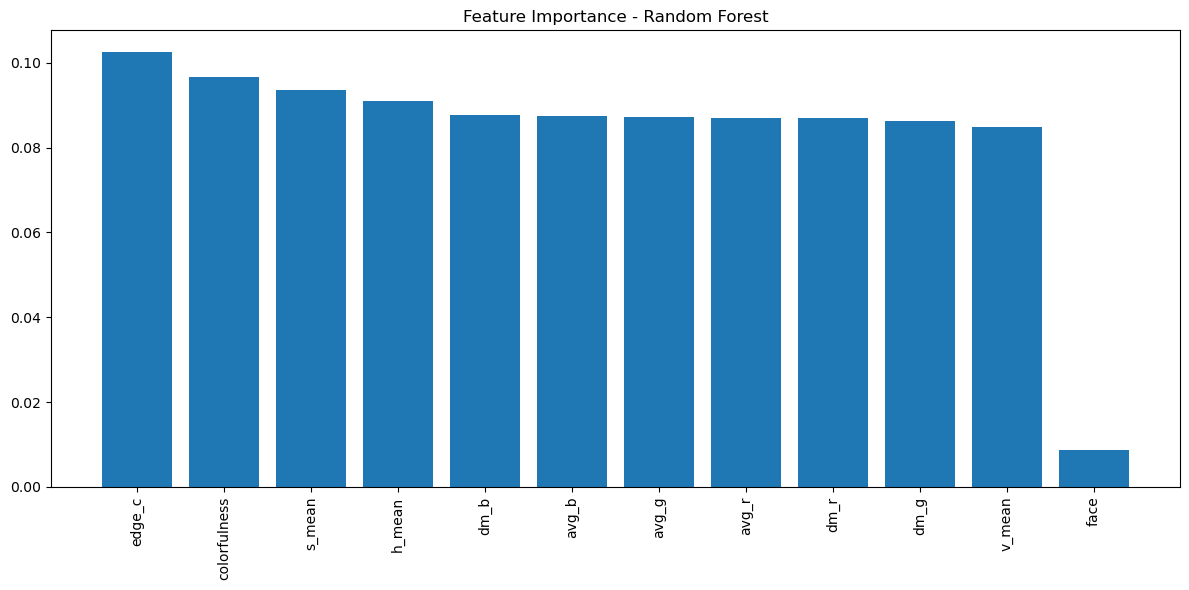

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("final_dataset_4moods.csv")
df = df.dropna()


audio_cols = ['avg_r', 'avg_g', 'avg_b', 'dm_r', 'dm_g', 'dm_b', 'edge_c', 'face', 'h_mean', 's_mean', 'v_mean', 'colorfulness']




features = df[audio_cols]
target = df['mood']


X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)


model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print(classification_report(y_test, y_pred))


importances = model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]


plt.figure(figsize=(12, 6))
plt.title("Feature Importance - Random Forest")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()


XGBOOST MODEL

/opt/anaconda3/envs/music-mood/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:58:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📊 Classification Report (XGBoost):
              precision    recall  f1-score   support

        Calm       0.18      0.03      0.05       201
   Energetic       0.55      0.76      0.64      1900
         Sad       0.37      0.08      0.13       391
    Stressed       0.49      0.40      0.44      1397

    accuracy                           0.53      3889
   macro avg       0.40      0.32      0.32      3889
weighted avg       0.49      0.53      0.49      3889



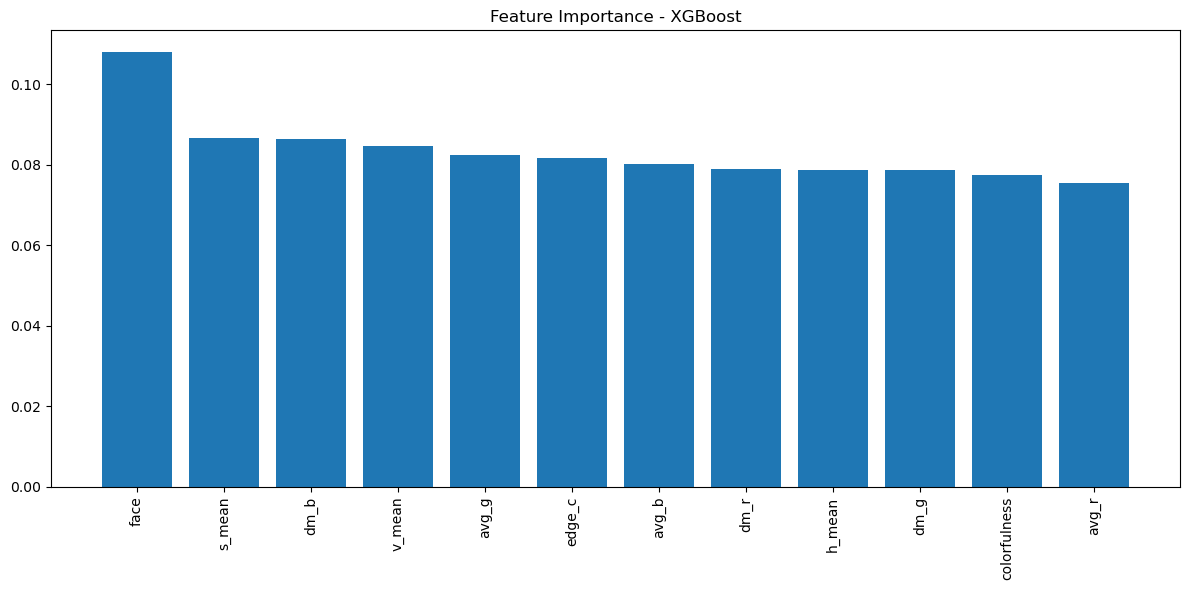

In [16]:
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)


xgb_model.fit(X_train, y_train_encoded)


y_pred_encoded = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)


print("📊 Classification Report (XGBoost):")
print(classification_report(y_test, y_pred))


importances = xgb_model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]


plt.figure(figsize=(12, 6))
plt.title("Feature Importance - XGBoost")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()




CLASS WEIGHT - XGBOOST MODEL

In [17]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)


xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)


xgb_model.fit(X_train, y_train_encoded, sample_weight=sample_weights)


y_pred_encoded = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)


print(classification_report(y_test, y_pred))

/opt/anaconda3/envs/music-mood/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:58:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

        Calm       0.13      0.19      0.15       201
   Energetic       0.57      0.54      0.56      1900
         Sad       0.21      0.25      0.23       391
    Stressed       0.47      0.44      0.45      1397

    accuracy                           0.46      3889
   macro avg       0.34      0.36      0.35      3889
weighted avg       0.48      0.46      0.47      3889



In [21]:
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, accuracy_score
from collections import Counter


smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train_encoded)


print("📊 Resampled class distribution after SMOTE:")
print(Counter(y_smote))

for label, count in Counter(y_smote).items():
    print(f"{le.inverse_transform([label])[0]}: {count}")


sample_weights_smote = compute_sample_weight(class_weight='balanced', y=y_smote)


best_params = {
    'n_estimators': 300,
    'max_depth': 10,
    'learning_rate': 0.1,
    'subsample': 0.6,
    'gamma': 0.2,
    'colsample_bytree': 0.8,
    'min_child_weight': 3
}

model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    **best_params
)


model.fit(X_smote, y_smote, sample_weight=sample_weights_smote)


y_pred_encoded = model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

print("\n📊 Classification Report (XGBoost + SMOTE):")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy with SMOTE: {round(acc, 4)}")


📊 Resampled class distribution after SMOTE:
Counter({np.int64(3): 7599, np.int64(1): 7599, np.int64(2): 7599, np.int64(0): 7599})
Stressed: 7599
Energetic: 7599
Sad: 7599
Calm: 7599


/opt/anaconda3/envs/music-mood/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [16:49:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Classification Report (XGBoost + SMOTE):
              precision    recall  f1-score   support

        Calm       0.13      0.13      0.13       201
   Energetic       0.59      0.65      0.61      1900
         Sad       0.22      0.18      0.20       391
    Stressed       0.49      0.45      0.47      1397

    accuracy                           0.50      3889
   macro avg       0.36      0.35      0.35      3889
weighted avg       0.49      0.50      0.50      3889

✅ Accuracy with SMOTE: 0.5035


In [22]:
from imblearn.over_sampling import ADASYN
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
import xgboost as xgb


adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train_encoded)


from collections import Counter



sample_weights = compute_sample_weight(class_weight='balanced', y=y_resampled)


best_params = {
    'n_estimators': 300,
    'max_depth': 10,
    'learning_rate': 0.1,
    'subsample': 0.6,
    'gamma': 0.2,
    'colsample_bytree': 0.8,
    'min_child_weight': 3
}

model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    **best_params
)


model.fit(X_resampled, y_resampled, sample_weight=sample_weights)


y_pred_encoded = model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)


print("\n📊 Classification Report (XGBoost + ADASYN):")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy with ADASYN: {round(acc, 4)}")


print("📊 Resampled class distribution after SMOTE:")
print(Counter(y_resampled))


for label, count in Counter(y_resampled).items():
    print(f"{le.inverse_transform([label])[0]}: {count}")

/opt/anaconda3/envs/music-mood/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [16:49:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Classification Report (XGBoost + ADASYN):
              precision    recall  f1-score   support

        Calm       0.12      0.13      0.13       201
   Energetic       0.58      0.62      0.60      1900
         Sad       0.24      0.19      0.21       391
    Stressed       0.48      0.45      0.46      1397

    accuracy                           0.49      3889
   macro avg       0.35      0.35      0.35      3889
weighted avg       0.48      0.49      0.49      3889

✅ Accuracy with ADASYN: 0.4914
📊 Resampled class distribution after SMOTE:
Counter({np.int64(0): 7929, np.int64(2): 7926, np.int64(1): 7599, np.int64(3): 6083})
Stressed: 6083
Energetic: 7599
Sad: 7926
Calm: 7929


CATBOOST MODEL

0:	learn: 1.3343633	total: 59.7ms	remaining: 17.8s
100:	learn: 1.0276646	total: 356ms	remaining: 701ms
200:	learn: 0.9826210	total: 662ms	remaining: 326ms
299:	learn: 0.9467647	total: 982ms	remaining: 0us
📊 Classification Report (CatBoost):
              precision    recall  f1-score   support

        Calm       0.00      0.00      0.00       201
   Energetic       0.53      0.84      0.65      1900
         Sad       0.56      0.04      0.07       391
    Stressed       0.49      0.30      0.37      1397

    accuracy                           0.52      3889
   macro avg       0.39      0.30      0.27      3889
weighted avg       0.49      0.52      0.46      3889



/opt/anaconda3/envs/music-mood/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/music-mood/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/music-mood/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

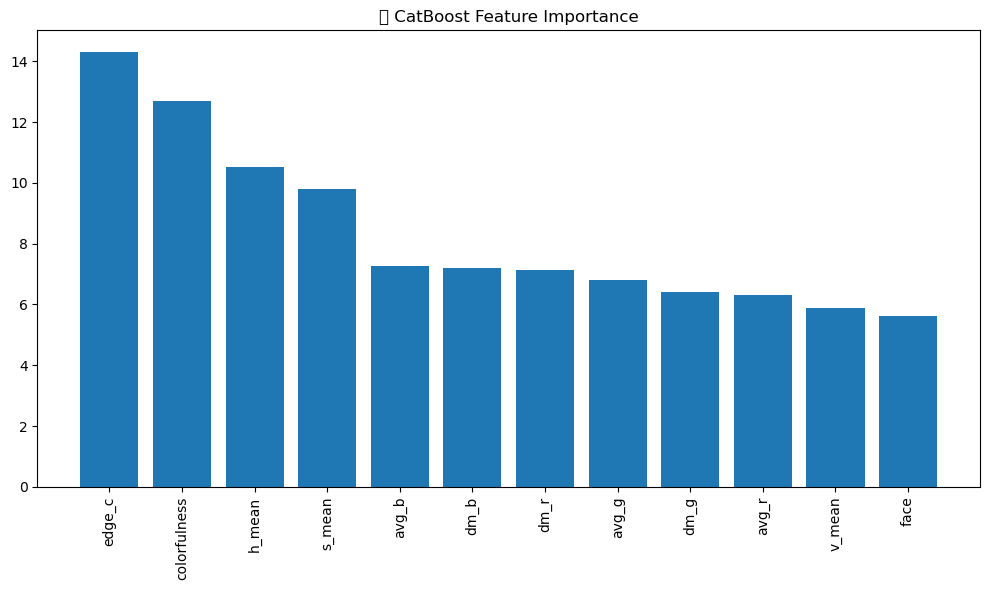

In [24]:
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import numpy as np


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    verbose=100,
    random_seed=42
)


cat_model.fit(X_train, y_train_encoded)


y_pred_encoded = cat_model.predict(X_test)
y_pred_encoded = y_pred_encoded.flatten()  # CatBoost çıktısı nested array olabilir
y_pred = le.inverse_transform(y_pred_encoded)


print("📊 Classification Report (CatBoost):")
print(classification_report(y_test, y_pred))
import matplotlib.pyplot as plt


feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'Feature {i}' for i in range(X_train.shape[1])]


importances = cat_model.get_feature_importance()
sorted_indices = np.argsort(importances)[::-1]


plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[sorted_indices], align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[sorted_indices], rotation=90)
plt.title("🔍 CatBoost Feature Importance")
plt.tight_layout()
plt.show()



PREPARE PARAMETERS

In [25]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
import numpy as np


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)


cat = CatBoostClassifier(
    loss_function='MultiClass',
    verbose=0,
    random_seed=42
)

param_dist = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}


NO CLASS WEİGHT 

In [26]:
print("🔁 RandomizedSearch WITHOUT class weights...\n")

random_search = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train_encoded)

print("✅ Best Params (No class weight):", random_search.best_params_)


y_pred = random_search.best_estimator_.predict(X_test)
y_pred = y_pred.flatten()
y_pred_labels = le.inverse_transform(y_pred)

print("\n📊 Classification Report (No class weight):")
print(classification_report(y_test, y_pred_labels))


🔁 RandomizedSearch WITHOUT class weights...

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END depth=6, iterations=200, l2_leaf_reg=5, learning_rate=0.05; total time=   3.6s
[CV] END depth=8, iterations=100, l2_leaf_reg=5, learning_rate=0.1; total time=   3.7s
[CV] END depth=6, iterations=200, l2_leaf_reg=5, learning_rate=0.05; total time=   3.7s
[CV] END depth=8, iterations=100, l2_leaf_reg=5, learning_rate=0.1; total time=   3.7s
[CV] END depth=6, iterations=200, l2_leaf_reg=5, learning_rate=0.05; total time=   3.8s
[CV] END depth=8, iterations=100, l2_leaf_reg=5, learning_rate=0.1; total time=   3.9s
[CV] END depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.05; total time=   1.9s
[CV] END depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.05; total time=   2.0s
[CV] END depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.05; total time=   2.0s
[CV] END depth=4, iterations=300, l2_leaf_reg=9, learning_rate=0.01; total time=   2.8s
[CV] END depth=8,

WITH CLASS WEIGHT

In [27]:
print("\n🔁 RandomizedSearch WITH class weights (via sample_weight)...\n")

random_search_weighted = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search_weighted.fit(X_train, y_train_encoded, sample_weight=sample_weights)

print("✅ Best Params (With class weight):", random_search_weighted.best_params_)


y_pred_weighted = random_search_weighted.best_estimator_.predict(X_test)
y_pred_weighted = y_pred_weighted.flatten()
y_pred_weighted_labels = le.inverse_transform(y_pred_weighted)

print("\n📊 Classification Report (With class weight):")
print(classification_report(y_test, y_pred_weighted_labels))



🔁 RandomizedSearch WITH class weights (via sample_weight)...

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END depth=6, iterations=200, l2_leaf_reg=5, learning_rate=0.05; total time=   3.2s
[CV] END depth=8, iterations=100, l2_leaf_reg=5, learning_rate=0.1; total time=   3.4s
[CV] END depth=8, iterations=100, l2_leaf_reg=5, learning_rate=0.1; total time=   3.4s
[CV] END depth=8, iterations=100, l2_leaf_reg=5, learning_rate=0.1; total time=   3.5s
[CV] END depth=6, iterations=200, l2_leaf_reg=5, learning_rate=0.05; total time=   3.7s
[CV] END depth=6, iterations=200, l2_leaf_reg=5, learning_rate=0.05; total time=   3.6s
[CV] END depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.05; total time=   1.7s
[CV] END depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.05; total time=   1.7s
[CV] END depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.05; total time=   1.9s
[CV] END depth=4, iterations=300, l2_leaf_reg=9, learning_rate=0.01; total time=   2.5s

In [28]:
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
from collections import Counter
import numpy as np


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train_encoded)


class_counts = Counter(y_resampled)
print("📊 Class distribution after SMOTE (encoded):")
for label, count in class_counts.items():
    mood_name = le.inverse_transform([label])[0]
    print(f"{mood_name}: {count} samples")


sample_weights = compute_sample_weight(class_weight='balanced', y=y_resampled)


cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=8,
    l2_leaf_reg=3,
    loss_function='MultiClass',
    verbose=100,
    random_seed=42
)


cat_model.fit(X_resampled, y_resampled, sample_weight=sample_weights)


y_pred_encoded = cat_model.predict(X_test).flatten()
y_pred = le.inverse_transform(y_pred_encoded)


print("\n📊 Classification Report (CatBoost + SMOTE + Class Weight + Best Params):")
print(classification_report(y_test, y_pred))


📊 Class distribution after SMOTE (encoded):
Stressed: 7599 samples
Energetic: 7599 samples
Sad: 7599 samples
Calm: 7599 samples
0:	learn: 1.3649833	total: 35.3ms	remaining: 10.6s
100:	learn: 1.0456924	total: 1.35s	remaining: 2.66s
200:	learn: 0.9178894	total: 2.62s	remaining: 1.29s
299:	learn: 0.8194449	total: 3.54s	remaining: 0us

📊 Classification Report (CatBoost + SMOTE + Class Weight + Best Params):
              precision    recall  f1-score   support

        Calm       0.10      0.18      0.13       201
   Energetic       0.56      0.60      0.58      1900
         Sad       0.20      0.17      0.18       391
    Stressed       0.48      0.39      0.43      1397

    accuracy                           0.46      3889
   macro avg       0.33      0.34      0.33      3889
weighted avg       0.47      0.46      0.46      3889



In [29]:
from catboost import CatBoostClassifier
from imblearn.over_sampling import ADASYN
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
from collections import Counter
import numpy as np


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train_encoded)


class_counts = Counter(y_resampled)
print("📊 Class distribution after ADASYN (encoded):")
for label, count in class_counts.items():
    mood_name = le.inverse_transform([label])[0]
    print(f"{mood_name}: {count} samples")


sample_weights = compute_sample_weight(class_weight='balanced', y=y_resampled)


cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=8,
    l2_leaf_reg=3,
    loss_function='MultiClass',
    verbose=100,
    random_seed=42
)


cat_model.fit(X_resampled, y_resampled, sample_weight=sample_weights)


y_pred_encoded = cat_model.predict(X_test).flatten()
y_pred = le.inverse_transform(y_pred_encoded)


print("\n📊 Classification Report (CatBoost + ADASYN + Class Weight + Best Params):")
print(classification_report(y_test, y_pred))


📊 Class distribution after ADASYN (encoded):
Stressed: 6083 samples
Energetic: 7599 samples
Sad: 7926 samples
Calm: 7929 samples
0:	learn: 1.3624624	total: 30.5ms	remaining: 9.13s
100:	learn: 1.0426064	total: 1.09s	remaining: 2.15s
200:	learn: 0.9254175	total: 2.19s	remaining: 1.08s
299:	learn: 0.8290971	total: 3.19s	remaining: 0us

📊 Classification Report (CatBoost + ADASYN + Class Weight + Best Params):
              precision    recall  f1-score   support

        Calm       0.11      0.19      0.14       201
   Energetic       0.57      0.55      0.56      1900
         Sad       0.20      0.17      0.19       391
    Stressed       0.47      0.46      0.46      1397

    accuracy                           0.46      3889
   macro avg       0.34      0.34      0.34      3889
weighted avg       0.47      0.46      0.47      3889



In [31]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
import numpy as np
audio_cols = ['avg_r', 'avg_g', 'avg_b', 'dm_r', 'dm_g', 'dm_b', 'edge_c', 'face', 'h_mean', 's_mean', 'v_mean', 'colorfulness']

top_features = [
'avg_r', 'avg_g', 'avg_b', 'dm_r', 'dm_g', 'dm_b', 'edge_c', 'h_mean', 's_mean', 'v_mean', 'colorfulness'
]


X_train_top = X_train[top_features]
X_test_top = X_test[top_features]


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)


cat = CatBoostClassifier(
    loss_function='MultiClass',
    verbose=0,
    random_seed=42
)


param_dist = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}

print("\n🔁 RandomizedSearch WITH class weights (via sample_weight)...\n")


random_search_weighted = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)


random_search_weighted.fit(X_train_top, y_train_encoded, sample_weight=sample_weights)


print("✅ Best Params (With class weight):", random_search_weighted.best_params_)

y_pred_weighted = random_search_weighted.best_estimator_.predict(X_test_top)
y_pred_weighted = y_pred_weighted.flatten()
y_pred_weighted_labels = le.inverse_transform(y_pred_weighted)


print("\n📊 Classification Report (CatBoost - Top 9 Features):")
print(classification_report(y_test, y_pred_weighted_labels))


🔁 RandomizedSearch WITH class weights (via sample_weight)...

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END depth=8, iterations=100, l2_leaf_reg=5, learning_rate=0.1; total time=   3.9s
[CV] END depth=6, iterations=200, l2_leaf_reg=5, learning_rate=0.05; total time=   3.9s
[CV] END depth=6, iterations=200, l2_leaf_reg=5, learning_rate=0.05; total time=   3.9s
[CV] END depth=8, iterations=100, l2_leaf_reg=5, learning_rate=0.1; total time=   4.0s
[CV] END depth=6, iterations=200, l2_leaf_reg=5, learning_rate=0.05; total time=   4.0s
[CV] END depth=8, iterations=100, l2_leaf_reg=5, learning_rate=0.1; total time=   4.2s
[CV] END depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.05; total time=   1.8s
[CV] END depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.05; total time=   2.0s
[CV] END depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.05; total time=   2.0s
[CV] END depth=4, iterations=300, l2_leaf_reg=9, learning_rate=0.01; total time=   2.9s

New Features

In [33]:
df['avg_rgb'] = (df['avg_r'] + df['avg_g'] + df['avg_b']) / 3
df['dm_rgb'] = (df['dm_r'] + df['dm_g'] + df['dm_b']) / 3
df['rgb_contrast'] = df['avg_rgb'] - df['dm_rgb']
df['color_dom_ratio'] = df['colorfulness'] / (df['dm_rgb'] + 1e-5)
df['hue_saturation_ratio'] = df['h_mean'] / (df['s_mean'] + 1e-5)
df['brightness'] = df['v_mean'] * df['s_mean']

In [34]:
new_features = [
'avg_r', 'avg_g', 'avg_b', 'dm_r', 'dm_g', 'dm_b', 'edge_c', 'face', 'h_mean', 's_mean', 'v_mean', 'colorfulness',
'avg_rgb','dm_rgb','rgb_contrast','color_dom_ratio','hue_saturation_ratio','brightness'
]

X = df[new_features]
y = df['mood']


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


XGBOOST

In [37]:
import xgboost as xgb
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight


new_features = [
'avg_r', 'avg_g', 'avg_b', 'dm_r', 'dm_g', 'dm_b', 'edge_c', 'face', 'h_mean', 's_mean', 'v_mean', 'colorfulness',
'avg_rgb','dm_rgb','rgb_contrast','color_dom_ratio','hue_saturation_ratio','brightness'
]

X = df[new_features]
y = df['mood']


le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.model_selection import train_test_split
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)


xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    subsample=0.6,
    n_estimators=300,
    min_child_weight=3,
    max_depth=10,
    learning_rate=0.1,
    gamma=0.2,
    colsample_bytree=0.8
)


xgb_model.fit(X_train, y_train_encoded, sample_weight=sample_weights)


y_pred_encoded = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)


print("📊 Classification Report (XGBoost with Engineered Features):")
print(classification_report(le.inverse_transform(y_test_encoded), y_pred))


/opt/anaconda3/envs/music-mood/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [16:55:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📊 Classification Report (XGBoost with Engineered Features):
              precision    recall  f1-score   support

        Calm       0.18      0.13      0.15       201
   Energetic       0.58      0.62      0.60      1900
         Sad       0.26      0.19      0.22       391
    Stressed       0.49      0.49      0.49      1397

    accuracy                           0.51      3889
   macro avg       0.38      0.36      0.37      3889
weighted avg       0.50      0.51      0.50      3889



CATBOOST 

In [38]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

new_features = [
'avg_r', 'avg_g', 'avg_b', 'dm_r', 'dm_g', 'dm_b', 'edge_c', 'face', 'h_mean', 's_mean', 'v_mean', 'colorfulness',
'avg_rgb','dm_rgb','rgb_contrast','color_dom_ratio','hue_saturation_ratio','brightness'
]

genre_cols = [col for col in df.columns if col.startswith("playlist_subgenre_")]
X = df[new_features]
y = df['mood']


le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)


cat_model = CatBoostClassifier(
    learning_rate=0.1,
    l2_leaf_reg=3,
    iterations=300,
    depth=8,
    loss_function='MultiClass',
    random_seed=42,
    verbose=100
)


cat_model.fit(X_train, y_train_encoded, sample_weight=sample_weights)


y_pred_encoded = cat_model.predict(X_test).flatten()
y_pred = le.inverse_transform(y_pred_encoded)


print("📊 Classification Report (CatBoost with Engineered Features):")
print(classification_report(le.inverse_transform(y_test_encoded), y_pred))


0:	learn: 1.3777545	total: 28.1ms	remaining: 8.39s
100:	learn: 1.1267178	total: 1.46s	remaining: 2.87s
200:	learn: 0.9743101	total: 2.83s	remaining: 1.39s
299:	learn: 0.8578474	total: 3.82s	remaining: 0us
📊 Classification Report (CatBoost with Engineered Features):
              precision    recall  f1-score   support

        Calm       0.13      0.27      0.17       201
   Energetic       0.60      0.51      0.55      1900
         Sad       0.18      0.27      0.21       391
    Stressed       0.48      0.43      0.46      1397

    accuracy                           0.44      3889
   macro avg       0.35      0.37      0.35      3889
weighted avg       0.49      0.44      0.46      3889

